In [2]:
# ============================================================
# CELL 1: LIBRARY IMPORTS AND QUESTION 1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
import openpyxl
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CREATE EXCEL FILE WITH MULTIPLE SHEETS
# ============================================================
excel_file = 'Answers.xlsx'
writer = pd.ExcelWriter(excel_file, engine='openpyxl')

# ============================================================
# QUESTION 1: FIND VARIABLES WITH MISSING DATA
# ============================================================
file_path = '/kaggle/input/datasets/chaymaebenaatia21/newdata/Take-home-case-Data-analyst(data).csv'
df = pd.read_csv(file_path)

# Count missing values per column
missing_counts = df.isnull().sum()
missing_variables = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("\nVariables with missing data:")
print("-" * 40)
for var, count in missing_variables.items():
    print(f"{var}: {count} missing values")
print(f"\nTotal: {len(missing_variables)} variables with missing data")

# Save to Excel - Sheet "Q1_Missing_Data"
missing_df = pd.DataFrame({
    'Variable': missing_variables.index,
    'Missing_Count': missing_variables.values,
    'Missing_Percentage': (missing_variables.values / len(df) * 100).round(1)
})
missing_df.to_excel(writer, sheet_name='Q1_Missing_Data', index=False)
print("\n Question 1 saved to sheet 'Q1_Missing_Data'")


Variables with missing data:
----------------------------------------
poolqc: 1453 missing values
miscfeature: 1406 missing values
alleyname: 1369 missing values
fence: 1179 missing values
masvnrtype: 872 missing values
fireplacequ: 690 missing values
frontge_lot: 259 missing values
garagetype: 81 missing values
garageyrblt: 81 missing values
garagefinish: 81 missing values
garagequal: 81 missing values
garagecond: 81 missing values
bsmtexposure: 38 missing values
bsmtfintype2: 38 missing values
bsmtqual: 37 missing values
bsmtcond: 37 missing values
bsmtfintype1: 37 missing values
masvnrarea: 8 missing values
electrical: 1 missing values

Total: 19 variables with missing data

 Question 1 saved to sheet 'Q1_Missing_Data'


id                    int64
sub_ms_class          int64
zoning_ms            object
frontge_lot         float64
area_lot              int64
streetname           object
alleyname            object
shape_lot            object
contour_land         object
util                 object
configlot            object
slopeland            object
neighborhood         object
c1                   object
c2                   object
type_building        object
style_house          object
ovl_quality           int64
ovl_condition         int64
year_constructed      int64
year_remod            int64
roof_style           object
roofmatl             object
ext1                 object
ext2                 object
masvnrtype           object
masvnrarea          float64
exterqual            object
extercond            object
foundation           object
bsmtqual             object
bsmtcond             object
bsmtexposure         object
bsmtfintype1         object
bsmtfinsf1            int64
bsmtfintype2        

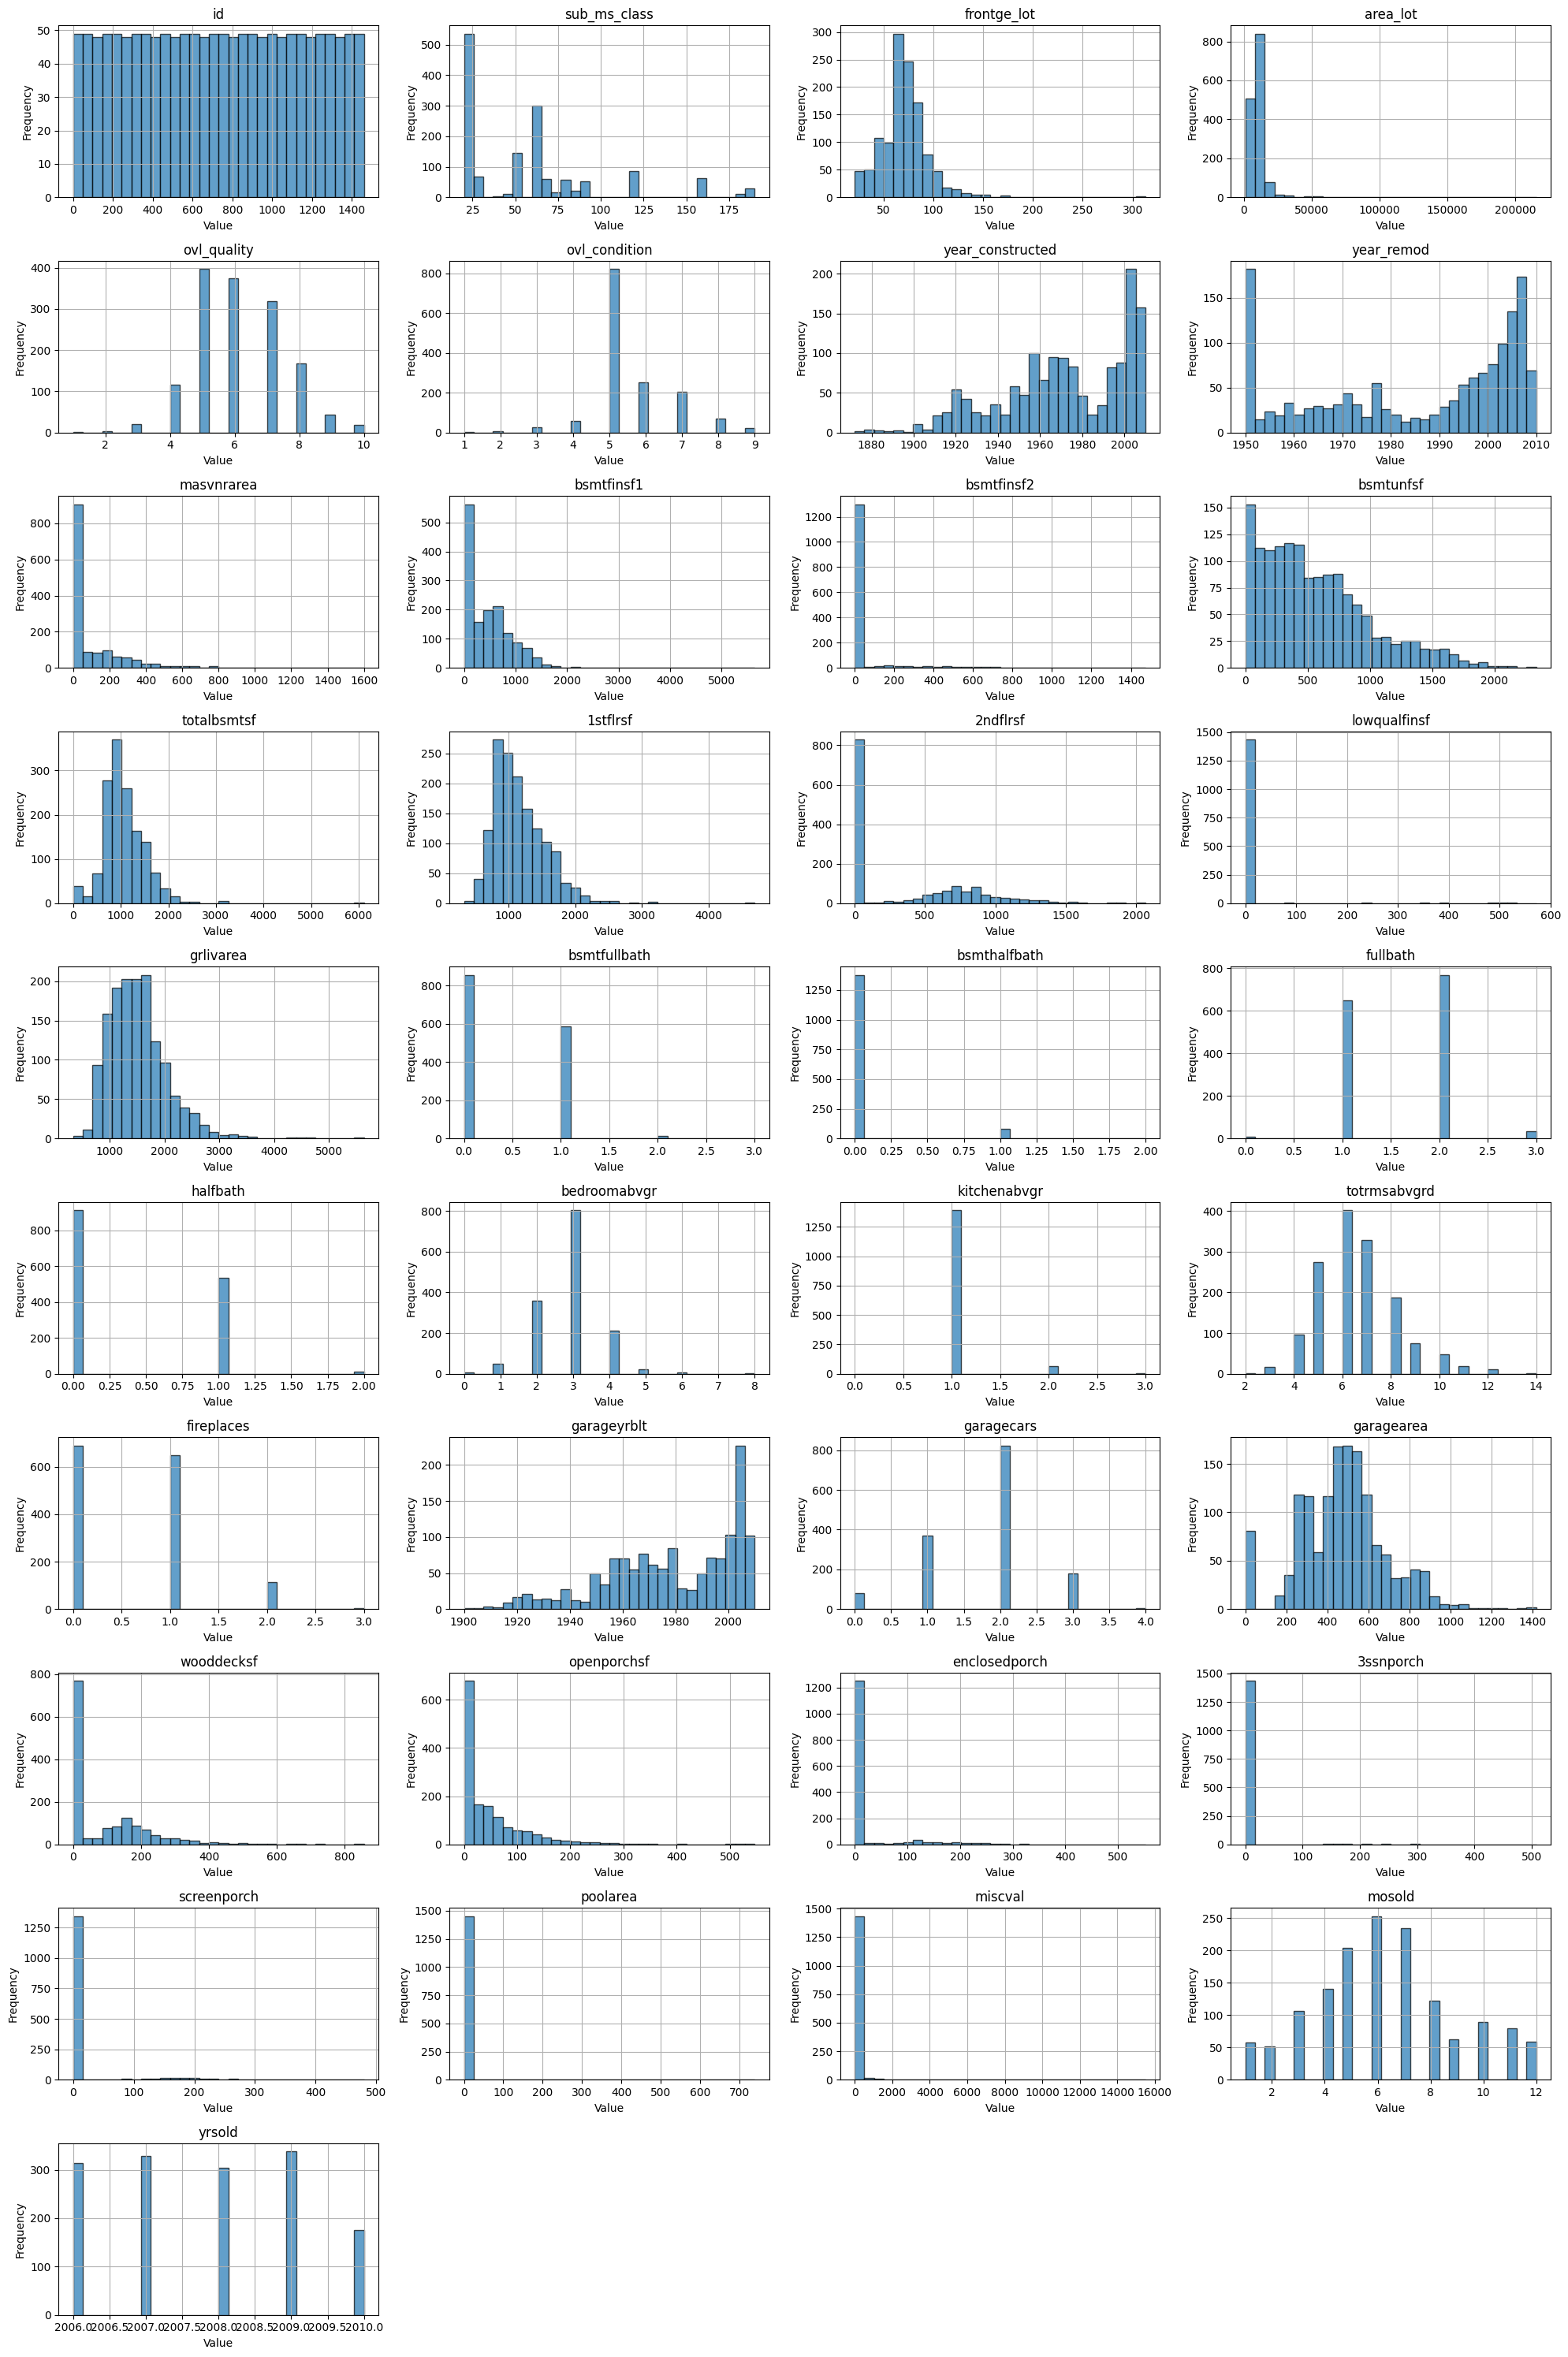

Histograms saved to 'numeric_histograms.png'
Number of categorical columns: 43
List of categorical columns (first 10):
  - zoning_ms
  - streetname
  - alleyname
  - shape_lot
  - contour_land
  - util
  - configlot
  - slopeland
  - neighborhood
  - c1
 Categorical columns list saved
 Category frequencies saved


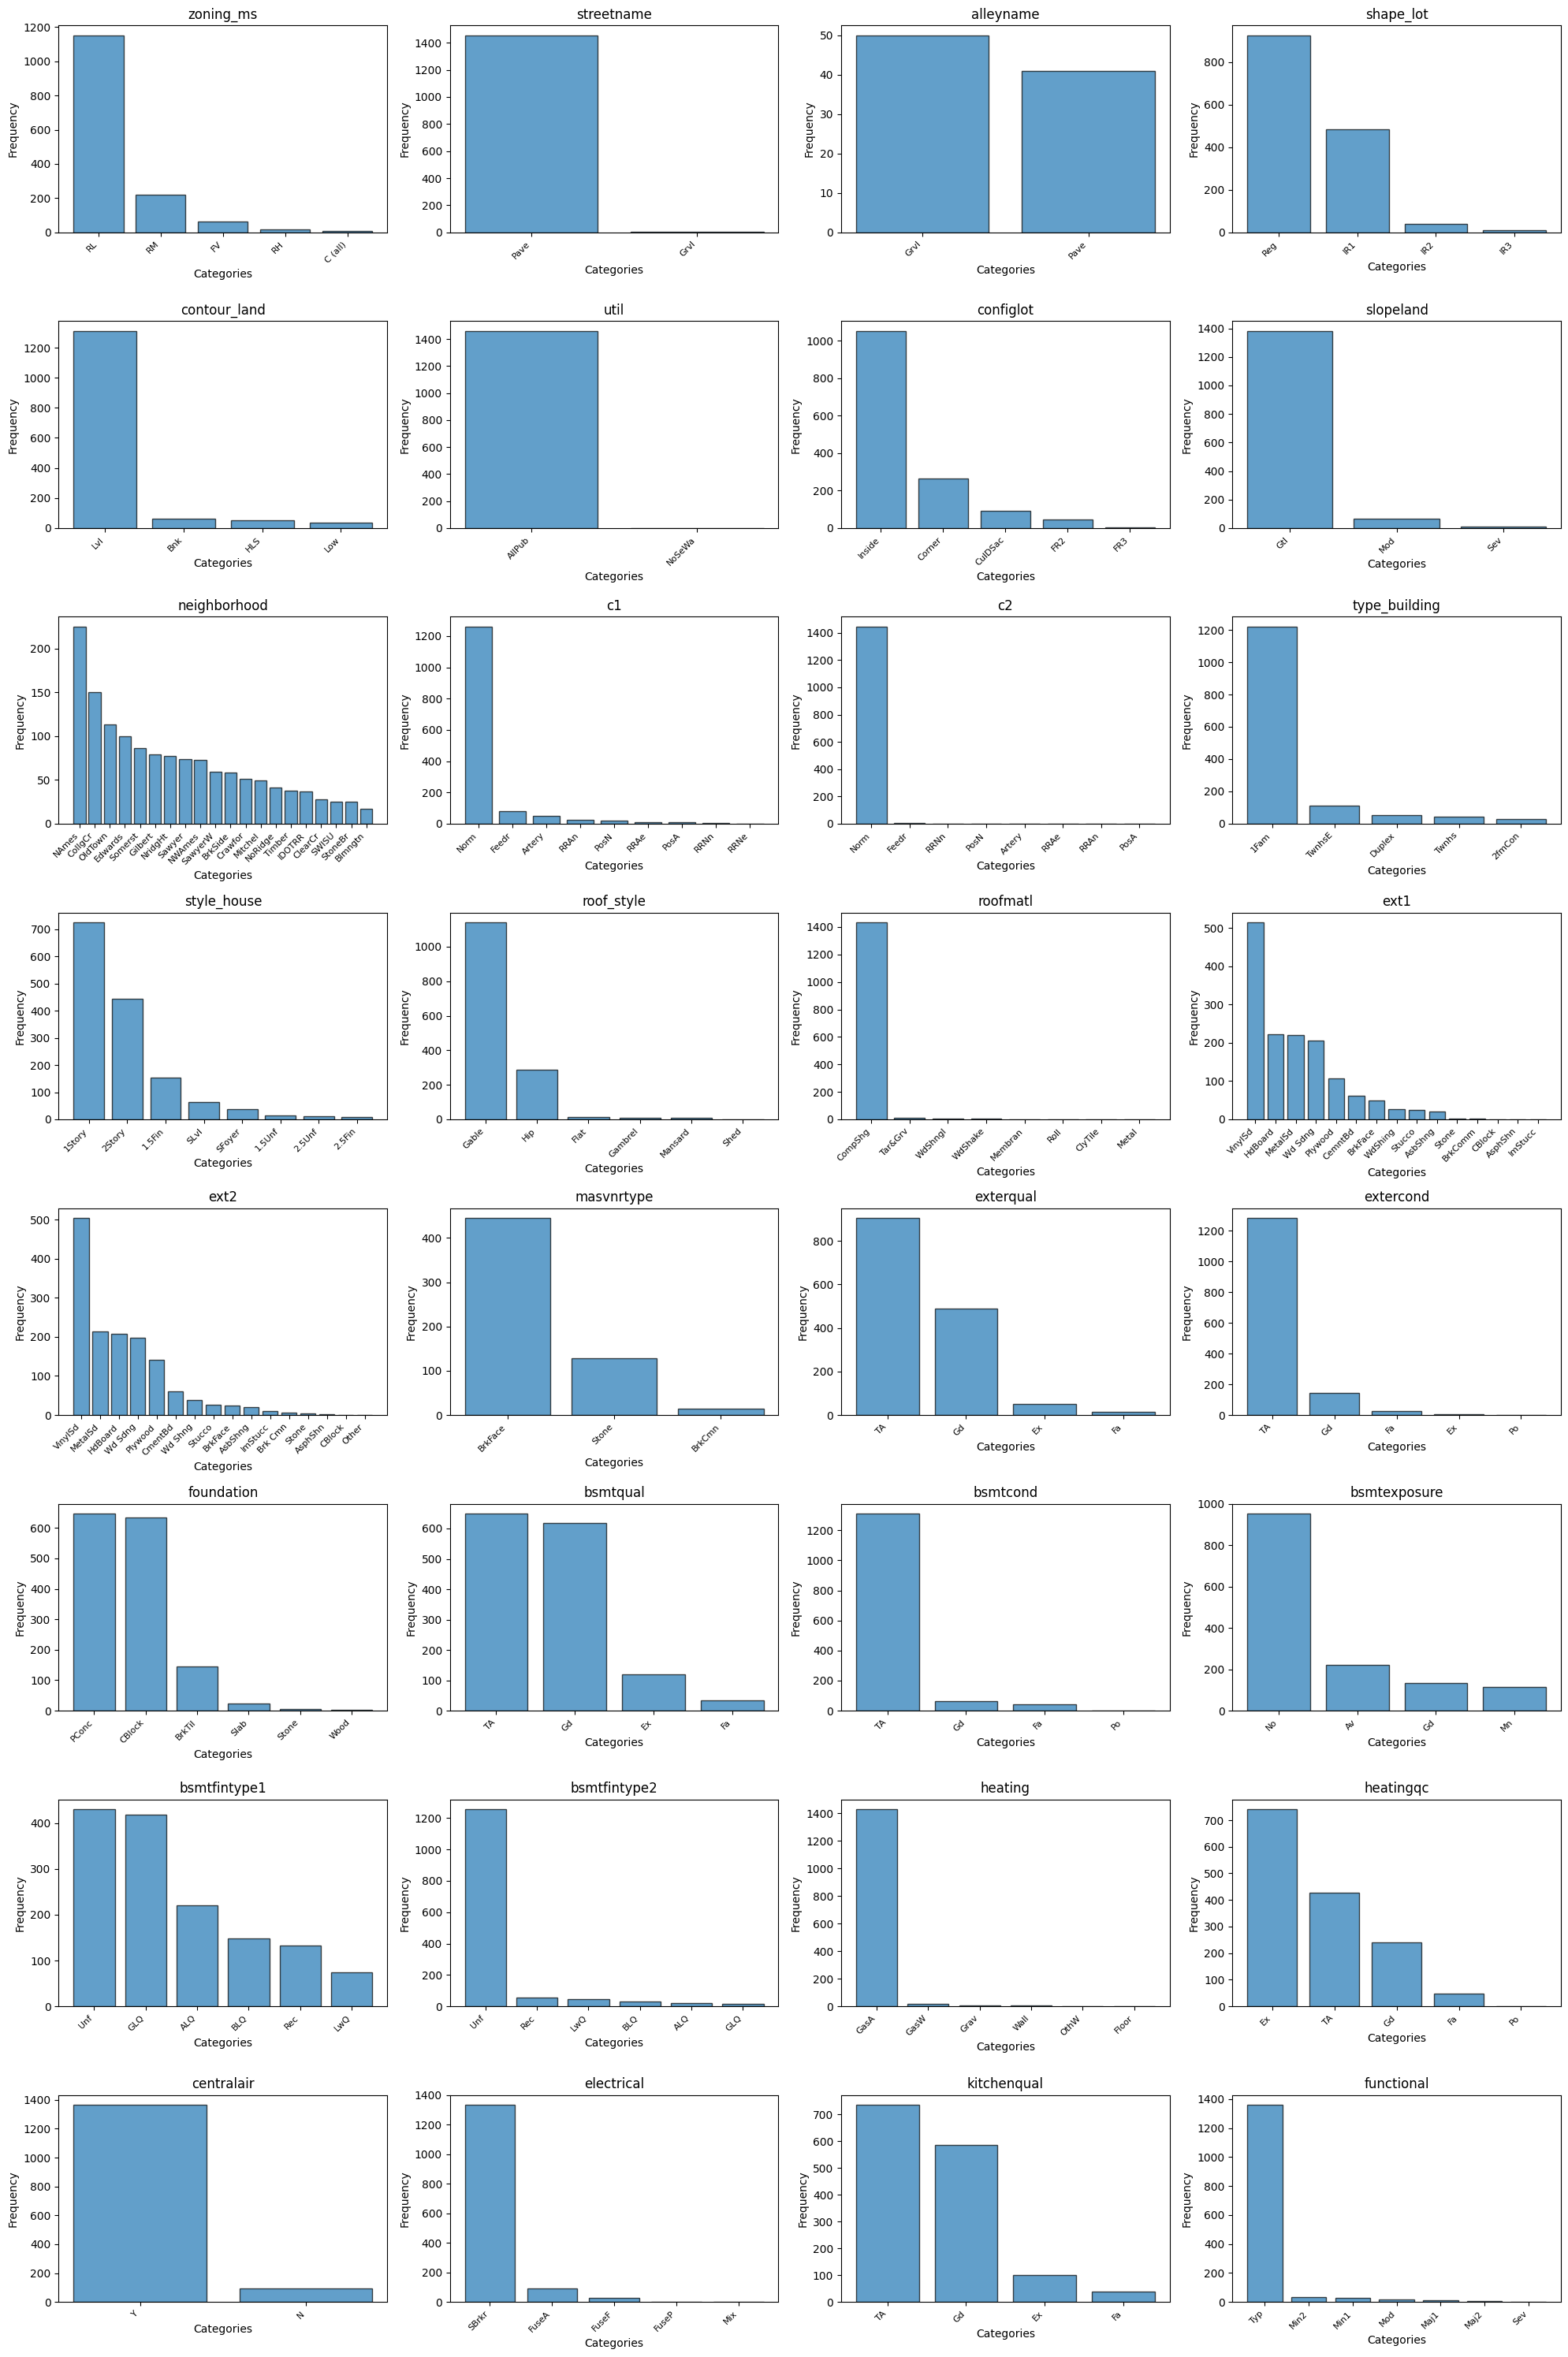

Frequency charts saved to 'categorical_histograms.png'
  - Imputed frontge_lot with median: 69.00
  - Imputed masvnrarea with median: 0.00
  - Imputed garageyrblt with median: 1980.00

Capped 868 outliers across all numeric columns
Missing values before imputation: 348
Missing values after imputation: 0
 Imputation and outlier logs saved

--- 5. Encoding Categorical Variables ---
Encoded 43 categorical columns
 Encoding log saved
Final feature matrix shape: (1460, 80)
Target vector shape: (1460,)
 Final data preview saved


In [3]:

# ------------------------------------------------------------------
# 1. Check data types for each column
# ------------------------------------------------------------------
print(df.dtypes.to_string())
print(f"\nTotal columns: {len(df.columns)}")

# Save to Excel - Sheet "Q2_Data_Types"
dtypes_df = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Non_Null_Count': len(df) - df.isnull().sum().values,
    'Null_Count': df.isnull().sum().values
})
dtypes_df.to_excel(writer, sheet_name='Q2_Data_Types', index=False)
print(" Data types saved to sheet 'Q2_Data_Types'")

# ------------------------------------------------------------------
# 2. Identify numeric columns and plot histograms
# ------------------------------------------------------------------
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove target from numeric cols for now (will add back later)
if 'saleprice' in numeric_cols:
    numeric_cols.remove('saleprice')
print(f"Number of numeric columns: {len(numeric_cols)}")
print("List of numeric columns (first 10):")
for col in numeric_cols[:10]:
    print(f"  - {col}")

# Save numeric columns list
numeric_cols_df = pd.DataFrame({
    'Numeric_Columns': numeric_cols,
    'Index': range(1, len(numeric_cols) + 1)
})
numeric_cols_df.to_excel(writer, sheet_name='Q2_Numeric_Columns', index=False)
print("Numeric columns list saved")

# Create histograms for numeric columns (first 40)
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(20, 30))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:40]):
    if i < len(axes):
        df[col].dropna().hist(bins=30, ax=axes[i], edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col}')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('numeric_histograms.png', dpi=100, bbox_inches='tight')
plt.show()
print("Histograms saved to 'numeric_histograms.png'")

# ------------------------------------------------------------------
# 3. Identify categorical columns and show frequency distributions
# ------------------------------------------------------------------
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Number of categorical columns: {len(categorical_cols)}")
print("List of categorical columns (first 10):")
for col in categorical_cols[:10]:
    print(f"  - {col}")

# Save categorical columns list
categorical_cols_df = pd.DataFrame({
    'Categorical_Columns': categorical_cols,
    'Index': range(1, len(categorical_cols) + 1)
})
categorical_cols_df.to_excel(writer, sheet_name='Q2_Categorical_Columns', index=False)
print(" Categorical columns list saved")

# Save categorical frequencies
cat_freq_data = []
for col in categorical_cols[:10]:  # Top 10 categorical
    value_counts = df[col].value_counts().head(10)
    for val, count in value_counts.items():
        cat_freq_data.append({
            'Column': col,
            'Category': val,
            'Frequency': count,
            'Percentage': round(count / len(df) * 100, 1)
        })

cat_freq_df = pd.DataFrame(cat_freq_data)
cat_freq_df.to_excel(writer, sheet_name='Q2_Cat_Frequencies', index=False)
print(" Category frequencies saved")

# Create frequency bar charts for categorical columns
fig, axes = plt.subplots(nrows=8, ncols=4, figsize=(20, 30))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:32]):
    if i < len(axes):
        value_counts = df[col].value_counts().head(20)  # Top 20 categories
        axes[i].bar(range(len(value_counts)), value_counts.values, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col}')
        axes[i].set_xlabel('Categories')
        axes[i].set_ylabel('Frequency')
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('categorical_histograms.png', dpi=100, bbox_inches='tight')
plt.show()
print("Frequency charts saved to 'categorical_histograms.png'")

# ------------------------------------------------------------------
# 4. Impute missing values and cap outliers
# -----------------------------------------------------------------
df_clean = df.copy()
imputation_log = []

# 4a. Impute missing numeric values with median
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        missing_before = df_clean[col].isnull().sum()
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)
        print(f"  - Imputed {col} with median: {median_value:.2f}")
        imputation_log.append({
            'Column': col,
            'Type': 'Numeric',
            'Missing_Before': missing_before,
            'Imputation_Method': 'Median',
            'Imputation_Value': round(median_value, 2)
        })

# 4b. Cap outliers using IQR method (3 * IQR)
outlier_count = 0
outlier_log = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    # Count outliers before capping
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
    if outliers > 0:
        outlier_count += outliers
        outlier_log.append({
            'Column': col,
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2),
            'Outliers_Capped': outliers
        })

    # Cap values
    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

print(f"\nCapped {outlier_count} outliers across all numeric columns")
print(f"Missing values before imputation: {df[numeric_cols].isnull().sum().sum()}")
print(f"Missing values after imputation: {df_clean[numeric_cols].isnull().sum().sum()}")

# Save imputation and outlier logs
imputation_df = pd.DataFrame(imputation_log)
imputation_df.to_excel(writer, sheet_name='Q4_Imputation_Log', index=False)

outlier_df = pd.DataFrame(outlier_log)
outlier_df.to_excel(writer, sheet_name='Q4_Outlier_Log', index=False)

print(" Imputation and outlier logs saved")

# ------------------------------------------------------------------
# 5. Prepare data for modeling (encode categorical variables)
# ------------------------------------------------------------------
print("\n--- 5. Encoding Categorical Variables ---")

# Create encoded dataframe from clean data
df_encoded = df_clean.copy()
encoding_log = []

# Encode categorical variables (fill NaNs with 'Missing')
for col in categorical_cols:
    missing_before = df_encoded[col].isnull().sum()
    df_encoded[col] = LabelEncoder().fit_transform(
        df_encoded[col].fillna('Missing').astype(str)
    )
    encoding_log.append({
        'Column': col,
        'Missing_Handled': missing_before,
        'Unique_Values': len(df[col].dropna().unique()),
        'Encoded_Values': len(df_encoded[col].unique())
    })

print(f"Encoded {len(categorical_cols)} categorical columns")

# Save encoding log
encoding_df = pd.DataFrame(encoding_log)
encoding_df.to_excel(writer, sheet_name='Q5_Encoding_Log', index=False)
print(" Encoding log saved")

# Define target and features
target = 'saleprice'
feature_cols = numeric_cols + categorical_cols
X = df_encoded[feature_cols]
y = df_encoded[target]

print(f"Final feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Save final data preview
final_data_preview = pd.concat([
    X.head(10),
    y.head(10).to_frame('saleprice')
], axis=1)
final_data_preview.to_excel(writer, sheet_name='Q5_Final_Data_Preview', index=False)
print(" Final data preview saved")

In [4]:
# ------------------------------------------------------------------
# 6. Train/test split
# ------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled using StandardScaler")

# Save split information
split_info = pd.DataFrame({
    'Dataset': ['Training', 'Test'],
    'Samples': [len(X_train), len(X_test)],
    'Percentage': [80, 20]
})
split_info.to_excel(writer, sheet_name='Q6_Train_Test_Split', index=False)
print(" Train/test split info saved")

# ============================================================
# FEATURE SELECTION (DIMENSIONALITY REDUCTION)
# ============================================================
# Use Random Forest for feature importance
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

# Get feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# Select features with importance > 0.01 (or top 10 if too few)
important_features = importance_df[importance_df['importance'] > 0.01]['feature'].tolist()
if len(important_features) < 5:
    important_features = importance_df.head(10)['feature'].tolist()
    print(f"\nUsing top {len(important_features)} features")
else:
    print(f"\nSelected {len(important_features)} features with importance > 0.01")

# Save feature importance
importance_df.to_excel(writer, sheet_name='Q7_Feature_Importance', index=False)
print("Feature importance saved")

# Save selected features
selected_features_df = pd.DataFrame({
    'Selected_Features': important_features,
    'Rank': range(1, len(important_features) + 1)
})
selected_features_df.to_excel(writer, sheet_name='Q7_Selected_Features', index=False)
print(" Selected features saved")

# Create datasets with selected features
X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

# Scale selected features
scaler_selected = StandardScaler()
X_train_scaled_selected = scaler_selected.fit_transform(X_train_selected)
X_test_scaled_selected = scaler_selected.transform(X_test_selected)

Training set: 1168 samples
Test set: 292 samples
Features scaled using StandardScaler
 Train/test split info saved

Top 15 most important features:
         feature  importance
     ovl_quality    0.575036
       grlivarea    0.123140
     totalbsmtsf    0.032697
        2ndflrsf    0.029012
      bsmtfinsf1    0.024958
        1stflrsf    0.023253
    totrmsabvgrd    0.017266
        bsmtqual    0.016633
        area_lot    0.016602
      garagearea    0.014202
      garagecars    0.011648
year_constructed    0.008648
      year_remod    0.005736
    neighborhood    0.005650
        fullbath    0.005299

Selected 11 features with importance > 0.01
Feature importance saved
 Selected features saved



Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation R² score: 0.8581

Test set performance:
RMSE: 35007.68 €
R²: 0.7738
 Regression results saved


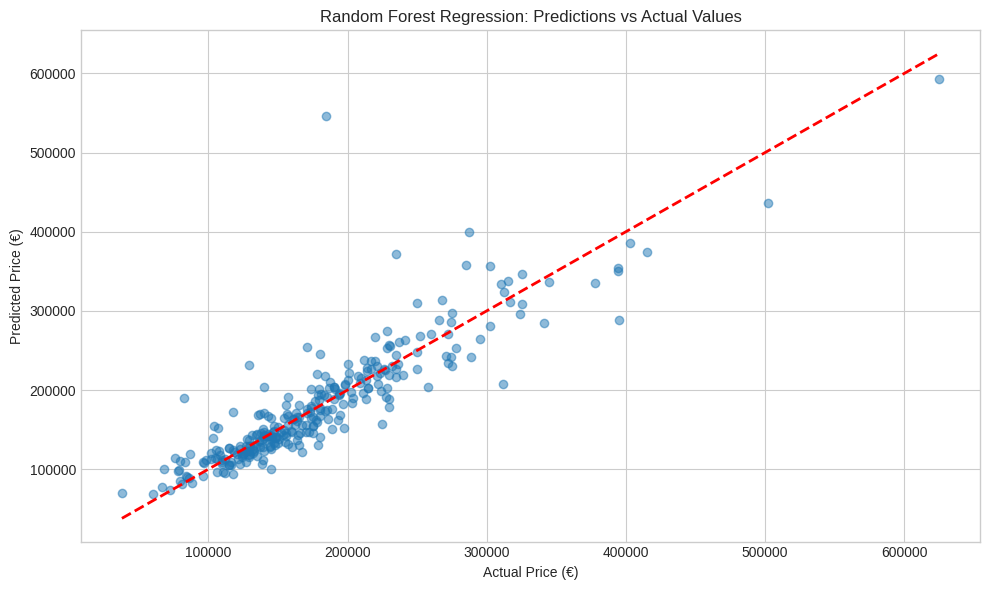

Regression plot saved to 'regression_results.png'
Clustering data shape: (1460, 11)
Data validated: No missing values

Evaluating cluster numbers:
  k=2: Silhouette=0.2524, DB=1.5398, Calinski=557
  k=3: Silhouette=0.2476, DB=1.4877, Calinski=465
  k=4: Silhouette=0.2139, DB=1.4725, Calinski=412
  k=5: Silhouette=0.1997, DB=1.5449, Calinski=372
  k=6: Silhouette=0.1834, DB=1.5623, Calinski=339
  k=7: Silhouette=0.1812, DB=1.6055, Calinski=308
 Cluster evaluation saved

Optimal number of clusters: 2 (Silhouette score: 0.2524)

Cluster distribution:
  Cluster 0: 892 properties, Average Price: 138136€ (±33747€)
  Cluster 1: 568 properties, Average Price: 248112€ (±83951€)
 Cluster distribution saved


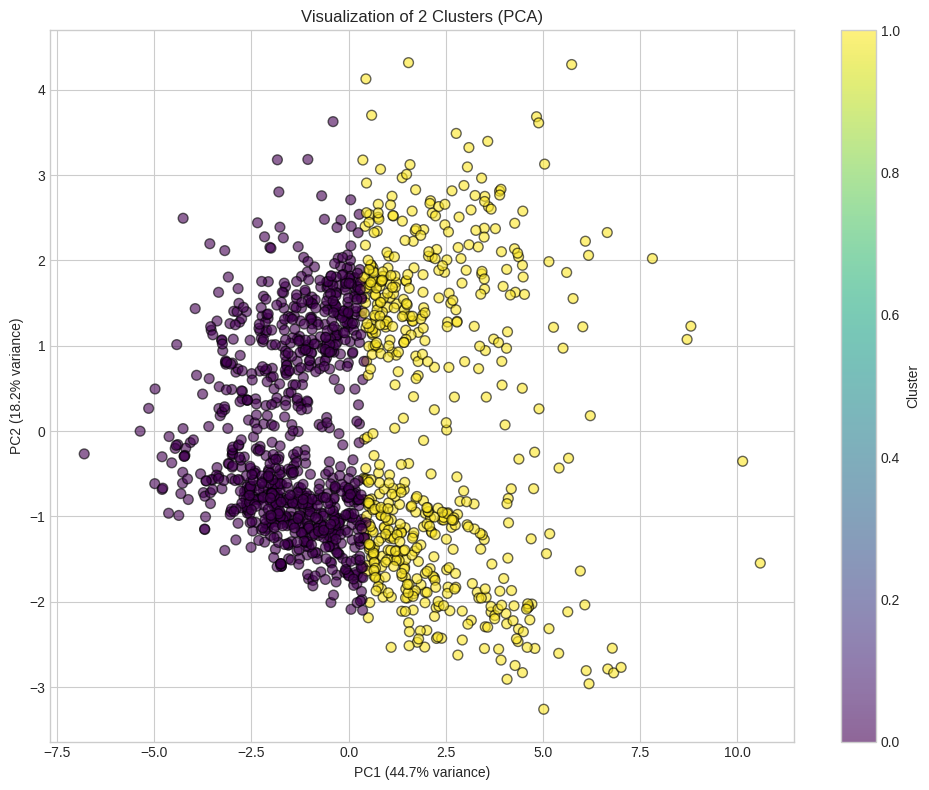

Cluster visualization saved to 'clusters_results.png'

--- REGRESSION MODEL (Random Forest) ---
RMSE (Root Mean Square Error): 35007.68 €
MAE (Mean Absolute Error): 20357.05 €
R² (Coefficient of Determination): 0.7738
MAPE (Mean Absolute Percentage Error): 12.05%
Cross-Validation R²: 0.8581 (±0.0470)
 Regression metrics saved

--- CLUSTERING MODEL (K-Means) ---

Cluster quality metrics for different k values:

  k=2:
    - Silhouette Score: 0.2524 (higher is better, >0.5 is good)
    - Davies-Bouldin Index: 1.5398 (lower is better)
    - Calinski-Harabasz Index: 557 (higher is better)
    - Inertia (WCSS): 11618

  k=3:
    - Silhouette Score: 0.2476 (higher is better, >0.5 is good)
    - Davies-Bouldin Index: 1.4877 (lower is better)
    - Calinski-Harabasz Index: 465 (higher is better)
    - Inertia (WCSS): 9806

  k=4:
    - Silhouette Score: 0.2139 (higher is better, >0.5 is good)
    - Davies-Bouldin Index: 1.4725 (lower is better)
    - Calinski-Harabasz Index: 412 (higher is bet

In [9]:
# ============================================================
# MODEL 1: REGRESSION - RANDOM FOREST WITH GRID SEARCH
# ============================================================


# Parameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Grid search with cross-validation
rf = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_selected, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best cross-validation R² score: {rf_grid.best_score_:.4f}")

# Evaluate on test set
y_pred = rf_grid.predict(X_test_selected)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nTest set performance:")
print(f"RMSE: {rmse:.2f} €")
print(f"R²: {r2:.4f}")

# Save regression results
regression_results = pd.DataFrame({
    'Metric': ['Best Parameters', 'Best CV R²', 'Test RMSE (€)', 'Test R²'],
    'Value': [str(rf_grid.best_params_), 
              f"{rf_grid.best_score_:.4f}", 
              f"{rmse:.2f}", 
              f"{r2:.4f}"]
})
regression_results.to_excel(writer, sheet_name='Q8_Regression_Results', index=False)
print(" Regression results saved")

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (€)')
plt.ylabel('Predicted Price (€)')
plt.title('Random Forest Regression: Predictions vs Actual Values')
plt.tight_layout()
plt.savefig('regression_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Regression plot saved to 'regression_results.png'")

# Use clean encoded data for clustering
X_cluster = df_encoded[important_features].copy()

# Scale clustering data
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Clustering data shape: {X_cluster_scaled.shape}")
print("Data validated: No missing values")

# Find optimal number of clusters using silhouette score
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []
inertia_scores = []
K_range = range(2, 8)

print("\nEvaluating cluster numbers:")
cluster_eval_data = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)

    silhouette = silhouette_score(X_cluster_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_cluster_scaled, labels)
    calinski = calinski_harabasz_score(X_cluster_scaled, labels)
    inertia = kmeans.inertia_

    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    calinski_scores.append(calinski)
    inertia_scores.append(inertia)

    print(f"  k={k}: Silhouette={silhouette:.4f}, DB={davies_bouldin:.4f}, Calinski={calinski:.0f}")
    
    cluster_eval_data.append({
        'k': k,
        'Silhouette_Score': round(silhouette, 4),
        'Davies_Bouldin': round(davies_bouldin, 4),
        'Calinski_Harabasz': int(calinski),
        'Inertia': int(inertia)
    })

# Save cluster evaluation
cluster_eval_df = pd.DataFrame(cluster_eval_data)
cluster_eval_df.to_excel(writer, sheet_name='Q9_Cluster_Evaluation', index=False)
print(" Cluster evaluation saved")

# Select optimal k (highest silhouette score)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_k} (Silhouette score: {max(silhouette_scores):.4f})")

# Final K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_cluster_scaled)

# Analyze clusters
df_with_clusters = df_encoded.copy()
df_with_clusters['cluster'] = clusters

print(f"\nCluster distribution:")
cluster_distribution = []

for i in range(optimal_k):
    count = sum(clusters == i)
    price_mean = df_with_clusters[df_with_clusters['cluster'] == i][target].mean()
    price_std = df_with_clusters[df_with_clusters['cluster'] == i][target].std()
    price_median = df_with_clusters[df_with_clusters['cluster'] == i][target].median()
    price_min = df_with_clusters[df_with_clusters['cluster'] == i][target].min()
    price_max = df_with_clusters[df_with_clusters['cluster'] == i][target].max()
    
    print(f"  Cluster {i}: {count} properties, Average Price: {price_mean:.0f}€ (±{price_std:.0f}€)")
    
    cluster_distribution.append({
        'Cluster': i,
        'Count': count,
        'Percentage': round(count / len(clusters) * 100, 1),
        'Mean_Price': round(price_mean, 0),
        'Std_Price': round(price_std, 0),
        'Median_Price': round(price_median, 0),
        'Min_Price': round(price_min, 0),
        'Max_Price': round(price_max, 0)
    })

# Save cluster distribution
cluster_dist_df = pd.DataFrame(cluster_distribution)
cluster_dist_df.to_excel(writer, sheet_name='Q9_Cluster_Distribution', index=False)
print(" Cluster distribution saved")

# Visualize clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, edgecolors='k', s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'Visualization of {optimal_k} Clusters (PCA)')
plt.tight_layout()
plt.savefig('clusters_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Cluster visualization saved to 'clusters_results.png'")


# ------------------------------------------------------------------
# Regression model - multiple metrics
# ------------------------------------------------------------------
print("\n--- REGRESSION MODEL (Random Forest) ---")

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Cross-validation scores
cv_scores = cross_val_score(
    rf_grid.best_estimator_,
    X_train_selected,
    y_train,
    cv=5,
    scoring='r2'
)

print(f"RMSE (Root Mean Square Error): {rmse:.2f} €")
print(f"MAE (Mean Absolute Error): {mae:.2f} €")
print(f"R² (Coefficient of Determination): {r2:.4f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print(f"Cross-Validation R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Save regression metrics
regression_metrics = pd.DataFrame({
    'Metric': ['RMSE (€)', 'MAE (€)', 'R²', 'MAPE (%)', 'CV R² Mean', 'CV R² Std'],
    'Value': [f"{rmse:.2f}", f"{mae:.2f}", f"{r2:.4f}", f"{mape:.2f}", 
              f"{cv_scores.mean():.4f}", f"{cv_scores.std():.4f}"]
})
regression_metrics.to_excel(writer, sheet_name='Q10_Regression_Metrics', index=False)
print(" Regression metrics saved")

# ------------------------------------------------------------------
# Clustering model - multiple metrics
# ------------------------------------------------------------------
print("\n--- CLUSTERING MODEL (K-Means) ---")

print("\nCluster quality metrics for different k values:")
cluster_metrics_data = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)

    silhouette = silhouette_score(X_cluster_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_cluster_scaled, labels)
    calinski = calinski_harabasz_score(X_cluster_scaled, labels)
    inertia = kmeans.inertia_

    print(f"\n  k={k}:")
    print(f"    - Silhouette Score: {silhouette:.4f} (higher is better, >0.5 is good)")
    print(f"    - Davies-Bouldin Index: {davies_bouldin:.4f} (lower is better)")
    print(f"    - Calinski-Harabasz Index: {calinski:.0f} (higher is better)")
    print(f"    - Inertia (WCSS): {inertia:.0f}")
    
    cluster_metrics_data.append({
        'k': k,
        'Silhouette_Score': round(silhouette, 4),
        'Davies_Bouldin': round(davies_bouldin, 4),
        'Calinski_Harabasz': int(calinski),
        'Inertia': int(inertia)
    })

# Save cluster metrics
cluster_metrics_df = pd.DataFrame(cluster_metrics_data)
cluster_metrics_df.to_excel(writer, sheet_name='Q10_Cluster_Metrics', index=False)
print(" Cluster metrics saved")

print(f"\nOptimal k based on Silhouette Score: {optimal_k}")


# ------------------------------------------------------------------
# Regression: best metric analysis
# ------------------------------------------------------------------

print("\nRecommended metric: MAPE (Mean Absolute Percentage Error)")
print("\nReasoning:")

# Calculate example error for a €200,000 house
example_error = 200000 * mape / 100

reasoning_reg = f"""
1. Business Context:
   - The real estate company needs accurate property pricing
   - Different price ranges require different error tolerances

2. Metric Comparison:
   - RMSE ({rmse:.2f}€): Penalizes large errors but is scale-dependent
   - MAE ({mae:.2f}€): Easy to interpret but not scale-independent
   - R² ({r2:.4f}): Technical metric, difficult for business stakeholders
   - MAPE ({mape:.2f}%): Scale-independent and directly interpretable

3. Business Impact:
   - A MAPE of {mape:.2f}% means predictions are off by ~{mape:.1f}% on average
   - For a €200,000 house, average error ≈ €{example_error:.0f}
   - Helps define pricing ranges: price ± MAPE%
   - Enables performance tracking: 'reduce MAPE from X% to Y%'
"""

print(reasoning_reg)

if mape <= 15:
    verdict = " Verdict: Model is business-ready (MAPE < 15%)"
else:
    verdict = " Verdict: Model needs improvement (MAPE > 15%)"
print(f"\n{verdict}")

# ------------------------------------------------------------------
# Clustering: best metric analysis
# ------------------------------------------------------------------

print("\nRecommended metric: Silhouette Score")
print("\nReasoning:")

silhouette_optimal = max(silhouette_scores)

reasoning_clust = f"""
1. Business Context:
   - Company aims to identify distinct property segments
   - Clusters should be internally consistent and well separated

2. Metric Comparison:
   - Silhouette Score: Measures cohesion and separation (range: -1 to 1)
   - Davies-Bouldin: Average similarity between clusters (lower is better)
   - Calinski-Harabasz: Ratio of between-cluster to within-cluster variance
   - Inertia: Always decreases with more clusters, not sufficient alone

3. Interpretation for Business:
"""

print(reasoning_clust)

if silhouette_optimal > 0.5:
    print("    Excellent segmentation (Silhouette > 0.5)")
    print("      - Clusters are well separated and meaningful")
    print("      - Each segment has distinct characteristics")
elif silhouette_optimal > 0.3:
    print("    Acceptable segmentation (Silhouette > 0.3)")
    print("      - Structure identifiable but some overlap")
    print("      - Useful for preliminary marketing strategies")
else:
    print("    Weak segmentation (Silhouette < 0.3)")
    print("      - Clusters may not be meaningful")
    print("      - Consider more features or different algorithms")

print(f"\nCurrent Silhouette Score for k={optimal_k}: {silhouette_optimal:.4f}")

print("\n4. Business application:")

business_app_data = []
for i in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
    price_mean = cluster_data[target].mean()
    
    # Determine segment based on price
    if price_mean < 150000:
        segment = "Entry-level / Budget"
    elif price_mean < 250000:
        segment = "Mid-range / Family homes"
    else:
        segment = "Premium / Luxury"
    
    cluster_size = sum(clusters == i)
    percentage = (cluster_size / len(clusters)) * 100
    print(f"   - Cluster {i}: {segment} ({percentage:.0f}% of properties)")
    print(f"     Average price: €{price_mean:.0f}")
    
    business_app_data.append({
        'Cluster': i,
        'Segment': segment,
        'Percentage': round(percentage, 1),
        'Average_Price': round(price_mean, 0)
    })

print("\n   Enables targeted marketing campaigns per segment:")
print("   • Budget segment: First-time buyer incentives, mortgage assistance")
print("   • Mid-range: Family-oriented messaging, school district highlights")
print("   • Premium: Investment opportunities, luxury features, exclusive events")

# Save business application
business_app_df = pd.DataFrame(business_app_data)
business_app_df.to_excel(writer, sheet_name='Q11_Business_Application', index=False)
print(" Business application saved")


summary = f"""
DATASET OVERVIEW:
-----------------
- Total observations: {len(df):,}
- Numeric features: {len(numeric_cols)}
- Categorical features: {len(categorical_cols)}
- Missing values handled: {missing_counts.sum()}

REGRESSION MODEL:
-----------------
- Algorithm: Random Forest with Grid Search
- Features used: {len(important_features)}
- Best parameters: {rf_grid.best_params_}
- RMSE: {rmse:.2f}€
- MAE: {mae:.2f}€
- R²: {r2:.4f}
- MAPE: {mape:.2f}%
- Business readiness: {" READY" if mape <= 15 else "!! NEEDS IMPROVEMENT"}

CLUSTERING MODEL:
-----------------
- Algorithm: K-Means
- Optimal clusters: {optimal_k}
- Silhouette score: {silhouette_optimal:.4f}
- Cluster distribution: {[int(sum(clusters == i)) for i in range(optimal_k)]}
- Business readiness: {"GOOD" if silhouette_optimal > 0.3 else "!FAIR"}

RECOMMENDATIONS:
----------------
1. Deploy regression model for price estimation with MAPE monitoring
2. Use {optimal_k} clusters for market segmentation and targeted campaigns
3. Collect more data (neighborhood trends, school ratings) to improve accuracy
4. Consider feature engineering (e.g., price per square meter, age of property)
5. Retrain models quarterly with new data to maintain accuracy
"""

print(summary)

# Save final summary
summary_lines = [line.strip() for line in summary.strip().split('\n') if line.strip()]
summary_df = pd.DataFrame({'Summary': summary_lines})
summary_df.to_excel(writer, sheet_name='Q12_Final_Summary', index=False)
print(" Final summary saved")

# Save and close the Excel file
writer.close()
print(f" Excel file saved as '{excel_file}' with all answer sheets")
